# Tarea 3

**Autor:** Alejandro Zarate Macias  

**Curso:** Reconocimiento de Patrones (ML)

**Fecha:** 16 de Febrero 2026

---

## Introducción

Esta tarea avanza el estudio del aprendizaje supervisado explorando modelos más complejos como Redes Neuronales y Máquinas de Vectores de Soporte (SVM). Se implementan ambos modelos en problemas de regresión y clasificación, tanto en conjuntos de datos reales como en funciones analíticas. Se analiza el proceso de backpropagation, se comparan con métodos de aproximación de gradientes, y se evalúa el desempeño de ambos modelos bajo diferentes hiperparámetros y configuraciones. Finalmente, se examina la interpretabilidad de los modelos y la importancia de la regularización en la generalización.

---

## Pre-requisitos

- Python 3.9 o superior
- Librerías:
    - numpy
    - matplotlib
    - notebook
    - pandas
    - scikit-learn
    - kagglehub[pandas-datasets]
    - ipywidgets

---

# Problema 2

Considere el conjunto de datos de `2022 Fuel Consumption Ratings`. Cree un script de Python para resolver el problema de regresión de pronóstico del consumo de combustible en ciudad y carretera con `sklearn`. Utilice un solo modelo `NN` para las dos categorías de consumo de combustible. Anote todos los supuestos, hiperparámetros y operaciones de preprocesamiento de datos que realice.

### Librerías

In [1]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Carga de datos

In [2]:
file_path = "MY2022 Fuel Consumption Ratings.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rinichristy/2022-fuel-consumption-ratings",
    file_path
)

In [3]:
df.head()

,Model Year,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption (City (L/100 km),Fuel Consumption(Hwy (L/100 km)),Fuel Consumption(Comb (L/100 km)),Fuel Consumption(Comb (mpg)),CO2 Emissions(g/km),CO2 Rating,Smog Rating
0,2022,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,200,6,3
1,2022,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263,4,5
2,2022,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,Z,11.0,8.6,9.9,29,232,5,6
3,2022,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,Z,11.3,9.1,10.3,27,242,5,6
4,2022,Acura,TLX SH-AWD,Compact,2.0,4,AS10,Z,11.2,8.0,9.8,29,230,5,7


### Preprocesamiento de Datos

In [4]:
# Seleccion de features y variables objetivo

# X:
# Variables numericas: 'Engine Size(L)', 'Cylinders'
# Variables categoricas: 'Vehicle Class', 'Transmission', 'Fuel Type'
X = df[['Engine Size(L)', 'Cylinders', 
        'Vehicle Class', 'Transmission', 'Fuel Type']]

# Manejo de variables categoricas con get_dummies
X = pd.get_dummies(X, columns=['Vehicle Class', 'Transmission', 'Fuel Type'], drop_first=True)


# y:
# Para el modelo de consumo en ciudad
y_city = df['Fuel Consumption (City (L/100 km)']

# Para el modelo de consumo en carretera
y_hwy = df['Fuel Consumption(Hwy (L/100 km))']

In [5]:
# Split de datos en entrenamiento y prueba
X_train_city, X_test_city, y_train_city, y_test_city = train_test_split(X, y_city, test_size=0.2, random_state=14)
X_train_hwy, X_test_hwy, y_train_hwy, y_test_hwy = train_test_split(X, y_hwy, test_size=0.2, random_state=14)

# Tamaño de los conjuntos de entrenamiento y prueba
print(f"Conjunto de entrenamiento ciudad: {X_train_city.shape} muestras")
print(f"Conjunto de prueba ciudad: {X_test_city.shape} muestras")
print(f"Conjunto de entrenamiento carretera: {X_train_hwy.shape} muestras")
print(f"Conjunto de prueba carretera: {X_test_hwy.shape} muestras")

Conjunto de entrenamiento ciudad: (756, 40) muestras
Conjunto de prueba ciudad: (190, 40) muestras
Conjunto de entrenamiento carretera: (756, 40) muestras
Conjunto de prueba carretera: (190, 40) muestras


### Entrenamiento

In [6]:
# Modelo de ciudad
model_city = MLPRegressor(
    loss='squared_error',
    hidden_layer_sizes=(200,), 
    activation='relu', 
    solver='adam', 
    max_iter=1500, 
    tol=1e-4,
    random_state=14
)
model_city.fit(X_train_city, y_train_city)
print("Modelo de Ciudad entrenado.")

Modelo de Ciudad entrenado.


In [7]:
# Modelo de carretera
model_hwy = MLPRegressor(
    loss='squared_error',
    hidden_layer_sizes=(200,), 
    activation='relu', 
    solver='adam', 
    max_iter=1500,
    tol=1e-4,
    random_state=14
)
model_hwy.fit(X_train_hwy, y_train_hwy)
print("Modelo de Carretera entrenado.")

Modelo de Carretera entrenado.


### Evaluación

In [8]:
# Metricas modelo de ciudad

y_pred_city = model_city.predict(X_test_city)
mse_city = mean_squared_error(y_test_city, y_pred_city)
rmse_city = mse_city ** 0.5
r2_city = r2_score(y_test_city, y_pred_city)

# Metricas modelo carretera

y_pred_hwy = model_hwy.predict(X_test_hwy)
mse_hwy = mean_squared_error(y_test_hwy, y_pred_hwy)
rmse_hwy = mse_hwy ** 0.5
r2_hwy = r2_score(y_test_hwy, y_pred_hwy)

# Tabla de resultados
print('-' * 60)
print(f"{'Modelo':<15} {'MSE':<15} {'RMSE':<15} {'R²':<15}")
print('-' * 60)
print(f"{'Ciudad':<15} {mse_city:<15.4f} {rmse_city:<15.4f} {r2_city:<15.4f}")
print(f"{'Carretera':<15} {mse_hwy:<15.4f} {rmse_hwy:<15.4f} {r2_hwy:<15.4f}")
print('-' * 60)

------------------------------------------------------------
Modelo          MSE             RMSE            R²             
------------------------------------------------------------
Ciudad          1.1425          1.0689          0.8884         
Carretera       0.7083          0.8416          0.8329         
------------------------------------------------------------


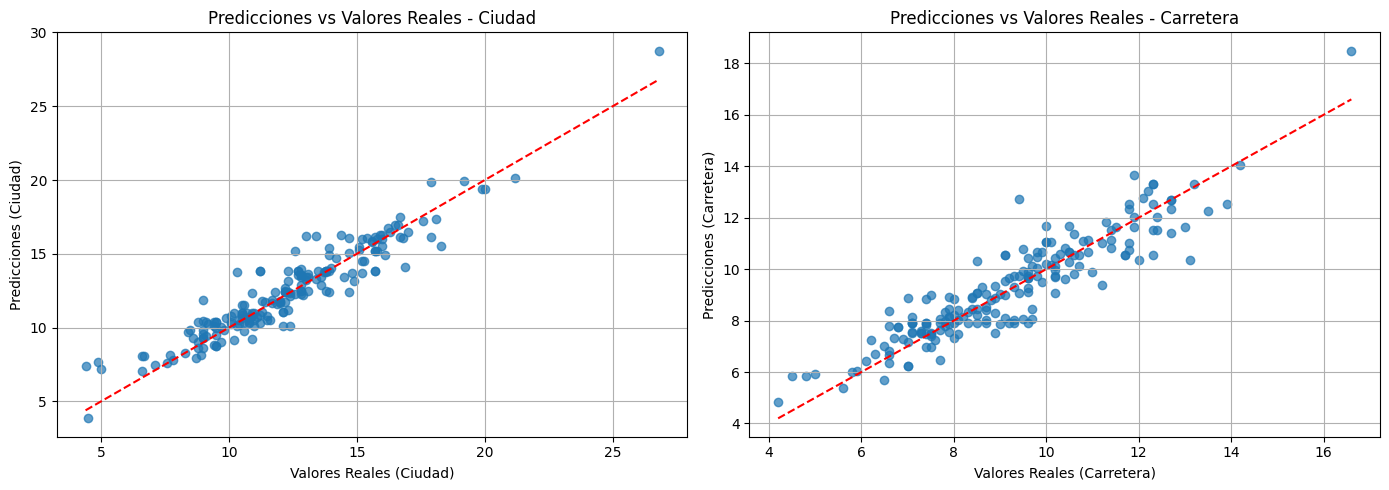

In [9]:
# Gráficas de predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica para Ciudad
axes[0].scatter(y_test_city, y_pred_city, alpha=0.7)
axes[0].plot([y_test_city.min(), y_test_city.max()], [y_test_city.min(), y_test_city.max()], 'r--')
axes[0].set_xlabel('Valores Reales (Ciudad)')
axes[0].set_ylabel('Predicciones (Ciudad)')
axes[0].set_title('Predicciones vs Valores Reales - Ciudad')
axes[0].grid()

# Gráfica para Carretera
axes[1].scatter(y_test_hwy, y_pred_hwy, alpha=0.7)
axes[1].plot([y_test_hwy.min(), y_test_hwy.max()], [y_test_hwy.min(), y_test_hwy.max()], 'r--')
axes[1].set_xlabel('Valores Reales (Carretera)')
axes[1].set_ylabel('Predicciones (Carretera)')
axes[1].set_title('Predicciones vs Valores Reales - Carretera')
axes[1].grid()

plt.tight_layout()
plt.show()

---

# Problema 3

Considere la siguiente función:

$f(x) = 1-2^{\sin(-x^2)}, \quad x \in \mathcal{I}[-\pi, \pi]$

Crea un script en Python para resolver el problema de regresión asociado a una red neuronal con sklearn. Anota todas las suposiciones que hagas. También anota los hiperparámetros que elijas y explica por qué los elegiste así.

### Librerías

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Carga de datos

In [11]:
# Generación de datos sintéticos
np.random.seed(14)
X = np.linspace(-np.pi, np.pi, 5000).reshape(-1, 1)
y = 1 - 2 ** (np.sin(-X.ravel() ** 2))

### Preprocesamiento de Datos

In [12]:
# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 4000 muestras
Conjunto de prueba: 1000 muestras


### Entrenamiento

In [13]:
model = MLPRegressor(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=2000,
    tol=1e-6,
    random_state=14
)
model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [14]:
# Métricas
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print('-' * 60)
print(f"{'Modelo':<15} {'MSE':<15} {'RMSE':<15} {'R²':<15}")
print('-' * 60)
print(f"{'f(x)':<15} {mse:<15.4f} {rmse:<15.4f} {r2:<15.4f}")
print('-' * 60)

------------------------------------------------------------
Modelo          MSE             RMSE            R²             
------------------------------------------------------------
f(x)            0.0435          0.2087          0.7710         
------------------------------------------------------------


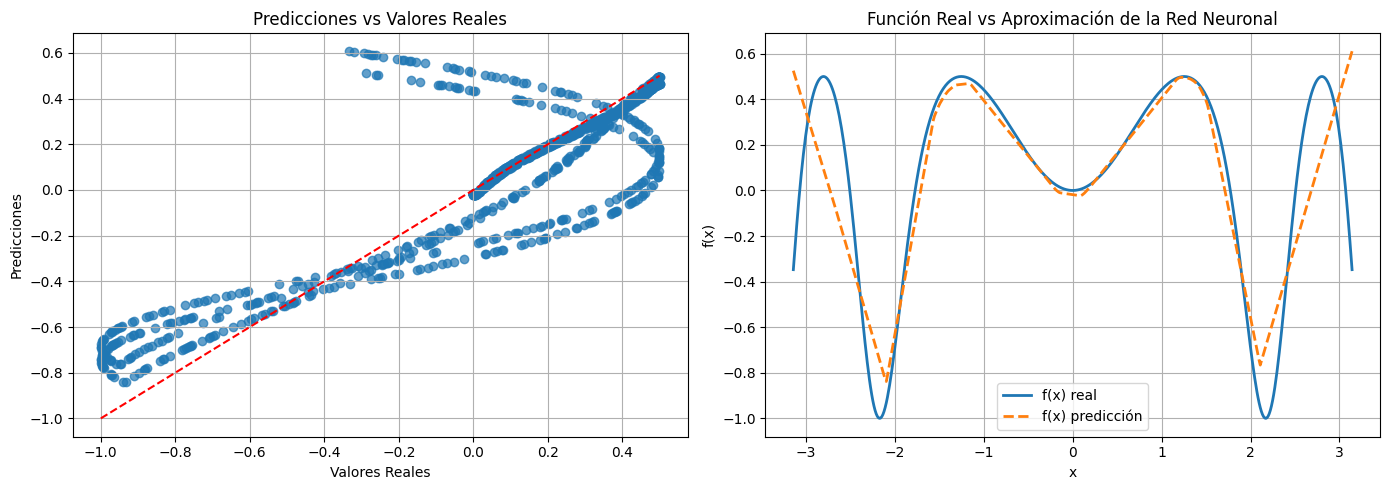

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicciones vs valores reales
axes[0].scatter(y_test, y_pred, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones')
axes[0].set_title('Predicciones vs Valores Reales')
axes[0].grid()

# Curva ajustada vs función real
X_plot = np.linspace(-np.pi, np.pi, 500).reshape(-1, 1)
y_plot_real = 1 - 2 ** (np.sin(-X_plot.ravel() ** 2))
y_plot_pred = model.predict(X_plot)

axes[1].plot(X_plot, y_plot_real, label='f(x) real', linewidth=2)
axes[1].plot(X_plot, y_plot_pred, label='f(x) predicción', linewidth=2, linestyle='--')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Función Real vs Aproximación de la Red Neuronal')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

---

# Problema 4

Considere el conjunto de datos de `horse.csv`. Cree un script con `sklearn` para resolver el problema de clasificación binaria asociado con determinar si un caballo determinado sobrevivirá o no. Utilice un modelo `NN`. Anote todas las suposiciones y operaciones de preprocesamiento de datos que realice. Incorpore la puntuación F1 para explicar sus hallazgos.

### Librerías

In [16]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from kagglehub import KaggleDatasetAdapter
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

### Carga de datos

In [17]:
file_path = "horse.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "yasserh/horsesurvivalprognostication",
    file_path
)

print(f"Dataset shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

Dataset shape: (299, 28)
Columnas: ['surgery', 'age', 'hospital_number', 'rectal_temp', 'pulse', 'respiratory_rate', 'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention', 'nasogastric_tube', 'nasogastric_reflux', 'nasogastric_reflux_ph', 'rectal_exam_feces', 'abdomen', 'packed_cell_volume', 'total_protein', 'abdomo_appearance', 'abdomo_protein', 'outcome', 'surgical_lesion', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data']

Valores nulos por columna:
surgery                    0
age                        0
hospital_number            0
rectal_temp               60
pulse                     24
respiratory_rate          58
temp_of_extremities       56
peripheral_pulse          69
mucous_membrane           47
capillary_refill_time     32
pain                      55
peristalsis               44
abdominal_distention      56
nasogastric_tube         104
nasogastric_reflux       106
nasogastric_reflux_ph    246
rec

### Preprocesamiento de Datos

In [18]:
# Variable objetivo binaria: lived = 1, died/euthanized = 0
df['outcome_binary'] = (df['outcome'] == 'lived').astype(int)
print(f"Distribución de clases:")
print(df['outcome_binary'].value_counts())

# Eliminar columnas no relevantes
cols_to_drop = ['outcome', 'hospital_number', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data']
df = df.drop(columns=cols_to_drop)

# Separar features y target
X = df.drop('outcome_binary', axis=1)
y = df['outcome_binary']

# Separar columnas numéricas y categóricas
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Imputar valores faltantes
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')
X[numeric_cols] = imputer_num.fit_transform(X[numeric_cols])
X[categorical_cols] = imputer_cat.fit_transform(X[categorical_cols])

# Codificación one-hot
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Distribución de clases:
outcome_binary
1    178
0    121
Name: count, dtype: int64


In [19]:
# División y normalización
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=14, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Conjunto de entrenamiento: {X_train_scaled.shape}")
print(f"Conjunto de prueba: {X_test_scaled.shape}")

Conjunto de entrenamiento: (239, 46)
Conjunto de prueba: (60, 46)


### Entrenamiento

In [20]:
model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=1500,
    tol=1e-5,
    random_state=14
)
model.fit(X_train_scaled, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [21]:
# Métricas
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('-' * 30)
print(f"{'Metrica':<20} {'Valor':<15}")
print('-' * 30)
print(f"{'Accuracy':<20} {acc:<15.4f}")
print(f"{'F1 (clase 1)':<20} {f1:<15.4f}")
print('-' * 30)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No sobrevivió', 'Sobrevivió']))

------------------------------
Metrica              Valor          
------------------------------
Accuracy             0.8000         
F1 (clase 1)         0.8421         
------------------------------

Reporte de clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.80      0.67      0.73        24
   Sobrevivió       0.80      0.89      0.84        36

     accuracy                           0.80        60
    macro avg       0.80      0.78      0.78        60
 weighted avg       0.80      0.80      0.80        60



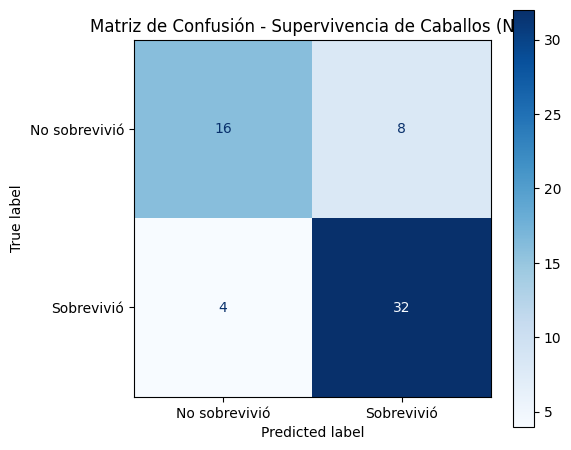

In [22]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No sobrevivió', 'Sobrevivió'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - Supervivencia de Caballos (NN)')
plt.tight_layout()
plt.show()

---

# Problema 5

Considere el conjunto de datos de `beer.csv`. Cree un script con `sklearn` para resolver el problema de clasificación multiclase asociado con la clasificación de cervezas por estilo. Utilice un modelo `NN`. Anote todas las suposiciones y operaciones de preprocesamiento de datos que realice. Luego, incorpore una matriz de confusión en su análisis.

### Librerías

In [23]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

### Carga de datos

In [24]:
file_path = "beer.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ankurnapa/ankurs-beer-data-set",
    file_path
)

df.head()

,Brew No.,OG,ABV,pH,IBU,style
0,1,11.5,4.2,4.20,14.0,Premium Lager
1,2,12.2,4.8,4.25,12.0,Premium Lager
2,3,13.0,5.0,3.80,13.0,Premium Lager
3,4,11.0,3.9,4.20,14.0,Premium Lager
4,5,12.0,4.2,3.90,12.0,Premium Lager


### Preprocesamiento de Datos

In [25]:
# Separar features y target
X = df.drop(['style', 'Brew No.'], axis=1)
y = df['style']

print(f"Shape: {X.shape}")
print(f"Número de clases: {y.nunique()}")
print(f"Clases: {sorted(y.unique())}")

Shape: (150, 4)
Número de clases: 3
Clases: ['IPA', 'Light Lager', 'Premium Lager']


In [26]:
# División y normalización
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.9, random_state=14, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Conjunto de entrenamiento: {X_train_scaled.shape}")
print(f"Conjunto de prueba: {X_test_scaled.shape}")

Conjunto de entrenamiento: (15, 4)
Conjunto de prueba: (135, 4)


### Entrenamiento

In [27]:
model = MLPClassifier(
    hidden_layer_sizes=(200,),
    activation='relu',
    solver='adam',
    max_iter=1500,
    tol=1e-4,
    random_state=14
)
model.fit(X_train_scaled, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [28]:
# Métricas
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print('-' * 30)
print(f"{'Metrica':<20} {'Valor':<15}")
print('-' * 30)
print(f"{'Accuracy':<20} {acc:<15.4f}")
print(f"{'F1 (macro)':<20} {f1_macro:<15.4f}")
print(f"{'F1 (weighted)':<20} {f1_weighted:<15.4f}")
print('-' * 30)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=sorted(y.unique())))

------------------------------
Metrica              Valor          
------------------------------
Accuracy             0.9926         
F1 (macro)           0.9926         
F1 (weighted)        0.9926         
------------------------------

Reporte de clasificación:
               precision    recall  f1-score   support

          IPA       1.00      0.98      0.99        45
  Light Lager       1.00      1.00      1.00        45
Premium Lager       0.98      1.00      0.99        45

     accuracy                           0.99       135
    macro avg       0.99      0.99      0.99       135
 weighted avg       0.99      0.99      0.99       135



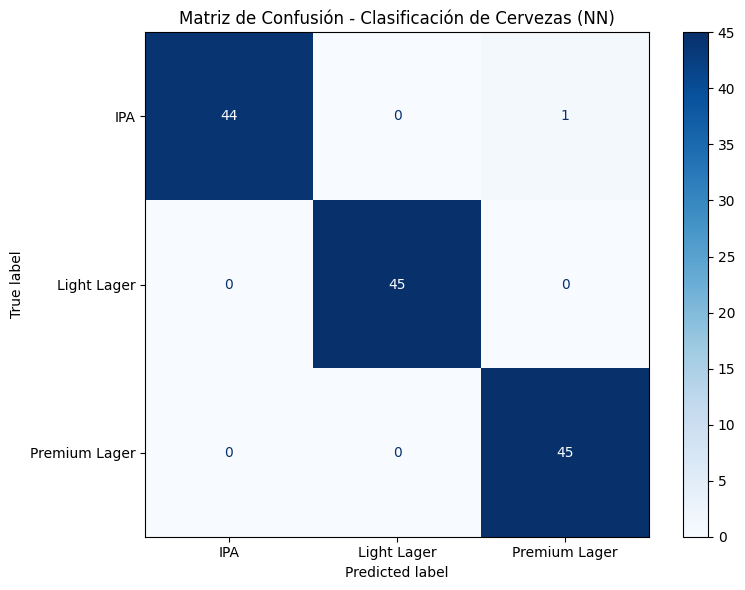

In [29]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - Clasificación de Cervezas (NN)')
plt.tight_layout()
plt.show()

---

# Problema 6

Consideremos la ecuación cuadrática general

$ax^2 + bx + c = 0$

Haz todo lo posible por clasificar las raíces de la ecuación anterior en función de sus coeficientes utilizando un modelo `NN` con `sklearn`. Para simplificar, debes fijar el dominio de $x$ y proponer un dominio adecuado para los coeficientes. Escribe todas tus suposiciones y muestra tus hallazgos con gráficos.

### Librerías

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

### Carga de datos

In [31]:
np.random.seed(14)

def generate_quadratic_data(n_samples=3000):
    data = []
    samples_per_class = n_samples // 3

    # Clase 2: Raíces reales distintas (Δ > 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        max_c = (b**2) / (4 * abs(a)) - 0.1
        c = np.random.uniform(-10, min(10, max_c))
        discriminant = b**2 - 4*a*c
        if discriminant > 0:
            data.append([a, b, c, 2])
            count += 1

    # Clase 1: Raíz real doble (Δ ≈ 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        c = (b**2) / (4 * a) + np.random.uniform(-0.05, 0.05)
        data.append([a, b, c, 1])
        count += 1

    # Clase 0: Raíces complejas (Δ < 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        min_c = (b**2) / (4 * abs(a)) + 0.1
        c = np.random.uniform(min(min_c, 10), 10)
        discriminant = b**2 - 4*a*c
        if discriminant < 0:
            data.append([a, b, c, 0])
            count += 1

    return pd.DataFrame(data, columns=['a', 'b', 'c', 'root_type'])

df = generate_quadratic_data(n_samples=3000)

print(f"Dataset generado: {df.shape[0]} ecuaciones cuadráticas")
print(f"Distribución por clase:")
print(df['root_type'].value_counts().sort_index())

Dataset generado: 3000 ecuaciones cuadráticas
Distribución por clase:
root_type
0    1000
1    1000
2    1000
Name: count, dtype: int64


### Preprocesamiento de Datos

In [32]:
# Separar features y target
X = df[['a', 'b', 'c']]
y = df['root_type']

# División y normalización
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Conjunto de entrenamiento: {X_train_scaled.shape}")
print(f"Conjunto de prueba: {X_test_scaled.shape}")

Conjunto de entrenamiento: (2400, 3)
Conjunto de prueba: (600, 3)


### Entrenamiento

In [33]:
model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=1500,
    tol=1e-6,
    random_state=14
)
model.fit(X_train_scaled, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [34]:
# Métricas
y_pred = model.predict(X_test_scaled)
class_names = ['Complejas\n(Δ<0)', 'Doble\n(Δ≈0)', 'Reales\n(Δ>0)']

train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
train_f1 = f1_score(y_train, model.predict(X_train_scaled), average='weighted')
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')

print("-" * 42)
print("Resultados del Modelo MLP")
print("-" * 42)
print(f"Train Accuracy: {train_acc:.4f}, Train F1: {train_f1:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}, Test F1:  {test_f1:.4f}")
print("-" * 42)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred,
                            target_names=['Complejas', 'Doble', 'Reales distintas']))

------------------------------------------
Resultados del Modelo MLP
------------------------------------------
Train Accuracy: 0.9775, Train F1: 0.9777
Test Accuracy:  0.9717, Test F1:  0.9718
------------------------------------------

Reporte de clasificación:
                  precision    recall  f1-score   support

       Complejas       0.98      0.98      0.98       200
           Doble       0.94      0.98      0.96       200
Reales distintas       1.00      0.95      0.98       200

        accuracy                           0.97       600
       macro avg       0.97      0.97      0.97       600
    weighted avg       0.97      0.97      0.97       600



<Figure size 800x600 with 0 Axes>

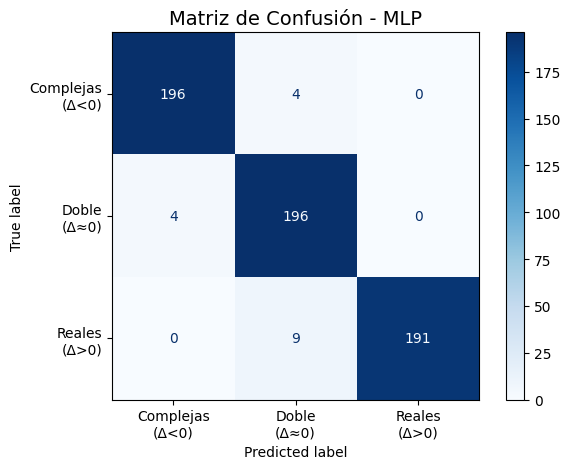

In [35]:
# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - MLP', fontsize=14)
plt.tight_layout()
plt.show()

---

# Problema 7

Considere el problema 3 con una red neuronal compuesta por una sola capa oculta con tres neuronas, funciones de activación logística para dichas neuronas y una función de activación lineal en la neurona de la capa de salida. Sea $x$ un punto aleatorio en $[-\pi, \pi]$. Con un script en Python, calcule y compare el gradiente de la red neuronal en $x$ mediante diferencias finitas centrales y backpropagation. Deberá utilizar las fórmulas del `problema 1`. Anote sus hallazgos y suposiciones.

### Librerías

In [36]:
import numpy as np

np.random.seed(14)

### Implementación

In [37]:
# Función objetivo (Problema 3)
def f(x):
    return 1 - 2 ** np.sin(-x ** 2)


# Red Neuronal: 1 entrada -> 3 ocultas (sigmoide) -> 1 salida (lineal)
class RedNeuronal:
    def __init__(self):
        self.W1 = np.random.randn(1, 3)
        self.b1 = np.random.randn(1, 3)
        self.W2 = np.random.randn(3, 1)
        self.b2 = np.random.randn(1, 1)

    @staticmethod
    def sigmoide(z):
        return 1.0 / (1.0 + np.exp(-z))

    def forward(self, x):
        self.x = x
        self.z1 = x @ self.W1 + self.b1
        self.a1 = self.sigmoide(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        return self.z2

    def mse(self, x, y_real):
        y_pred = self.forward(x)
        return 0.5 * (y_pred - y_real) ** 2

    def backpropagation(self, x, y_real):
        y_pred = self.forward(x)

        # Capa de salida
        delta2 = (y_pred - y_real)
        dC_dW2 = self.a1.T @ delta2
        dC_db2 = delta2.copy()

        # Capa oculta
        sigma_prima = self.a1 * (1 - self.a1)
        delta1 = (delta2 @ self.W2.T) * sigma_prima
        dC_dW1 = self.x.T @ delta1
        dC_db1 = delta1.copy()

        return dC_dW1, dC_db1, dC_dW2, dC_db2


# Diferencias finitas centrales
class DiferenciasFinitas:
    def __init__(self, W1, b1, W2, b2, h=1e-5):
        self.W1 = W1
        self.b1 = b1
        self.W2 = W2
        self.b2 = b2
        self.h = h

    @staticmethod
    def sigmoide(z):
        return 1.0 / (1.0 + np.exp(-z))

    def costo(self, x, y_real):
        z1 = x @ self.W1 + self.b1
        a1 = self.sigmoide(z1)
        y_pred = a1 @ self.W2 + self.b2
        return 0.5 * (y_pred - y_real) ** 2

    def gradiente(self, x, y_real):
        parametros = [self.W1, self.b1, self.W2, self.b2]
        gradientes = []

        for param in parametros:
            grad = np.zeros_like(param)
            for idx in np.ndindex(param.shape):
                original = param[idx]
                param[idx] = original + self.h
                C_mas = self.costo(x, y_real)
                param[idx] = original - self.h
                C_menos = self.costo(x, y_real)
                grad[idx] = (C_mas - C_menos) / (2 * self.h)
                param[idx] = original
            gradientes.append(grad)

        return gradientes

### Evaluación

In [38]:
# Punto aleatorio
x = np.random.uniform(-np.pi, np.pi)
x_mat = np.array([[x]])
y_real = f(x)

print(f"Punto aleatorio: x = {x:.6f}")
print(f"Valor real:      f(x) = {y_real:.6f}\n")

# Crear red y calcular predicción
red = RedNeuronal()
y_pred = red.forward(x_mat)
print(f"Predicción de la red: {y_pred[0,0]:.6f}")
print(f"Costo: {red.mse(x_mat, y_real)[0,0]:.6f}\n")

# Gradientes por backpropagation
grad_bp = red.backpropagation(x_mat, y_real)

# Gradientes por diferencias finitas
df_grad = DiferenciasFinitas(red.W1, red.b1, red.W2, red.b2)
grad_df = df_grad.gradiente(x_mat, y_real)

# Comparación
nombres = ['dC/dW1', 'dC/db1', 'dC/dW2', 'dC/db2']
print("-" * 80)
print(f"{'Parámetro':<12} {'Backpropagation':<25} {'Dif. Finitas':<25} {'Error abs':<15}")
print("-" * 80)
for nombre, g_bp, g_df in zip(nombres, grad_bp, grad_df):
    for idx in np.ndindex(g_bp.shape):
        bp_val = g_bp[idx]
        df_val = g_df[idx].item() if hasattr(g_df[idx], 'item') else g_df[idx]
        error = abs(bp_val - df_val)
        print(f"{nombre}{list(idx)!s:<8} {bp_val:<25.10f} {df_val:<25.10f} {error:<15.2e}")
print("-" * 80)

Punto aleatorio: x = 0.087609
Valor real:      f(x) = 0.005306

Predicción de la red: -1.932242
Costo: 1.877046

--------------------------------------------------------------------------------
Parámetro    Backpropagation           Dif. Finitas              Error abs      
--------------------------------------------------------------------------------
dC/dW1[0, 0]   -0.0246636910             -0.0246636910             1.89e-11       
dC/dW1[0, 1]   0.0235548857              0.0235548857              2.03e-11       
dC/dW1[0, 2]   -0.0094428536             -0.0094428536             2.10e-11       
dC/db1[0, 0]   -0.2815213055             -0.2815213055             2.74e-11       
dC/db1[0, 1]   0.2688649544              0.2688649544              4.39e-12       
dC/db1[0, 2]   -0.1077845349             -0.1077845349             5.31e-12       
dC/dW2[0, 0]   -1.2661128669             -1.2661128669             1.49e-11       
dC/dW2[1, 0]   -1.1828816191             -1.1828816191         

/tmp/ipykernel_478911/1076217615.py:77: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[idx] = (C_mas - C_menos) / (2 * self.h)


---

# Problema 8

Repita el problema 2 utilizando el modelo SVM de sklearn. Anote los hiperparámetros que elija y todas sus suposiciones.

### Librerías

In [39]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

### Carga de datos

In [40]:
file_path = "MY2022 Fuel Consumption Ratings.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rinichristy/2022-fuel-consumption-ratings",
    file_path
)

df.head()

,Model Year,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption (City (L/100 km),Fuel Consumption(Hwy (L/100 km)),Fuel Consumption(Comb (L/100 km)),Fuel Consumption(Comb (mpg)),CO2 Emissions(g/km),CO2 Rating,Smog Rating
0,2022,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,200,6,3
1,2022,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263,4,5
2,2022,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,Z,11.0,8.6,9.9,29,232,5,6
3,2022,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,Z,11.3,9.1,10.3,27,242,5,6
4,2022,Acura,TLX SH-AWD,Compact,2.0,4,AS10,Z,11.2,8.0,9.8,29,230,5,7


### Preprocesamiento de Datos

In [41]:
# Selección de features y variables objetivo
X = df[['Engine Size(L)', 'Cylinders',
        'Vehicle Class', 'Transmission', 'Fuel Type']]
X = pd.get_dummies(X, columns=['Vehicle Class', 'Transmission', 'Fuel Type'], drop_first=True)

y_city = df['Fuel Consumption (City (L/100 km)']
y_hwy = df['Fuel Consumption(Hwy (L/100 km))']

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
# División de datos
X_train_city, X_test_city, y_train_city, y_test_city = train_test_split(
    X_scaled, y_city, test_size=0.2, random_state=14)
X_train_hwy, X_test_hwy, y_train_hwy, y_test_hwy = train_test_split(
    X_scaled, y_hwy, test_size=0.2, random_state=14)

print(f"Conjunto de entrenamiento: {X_train_city.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test_city.shape[0]} muestras")

Conjunto de entrenamiento: 756 muestras
Conjunto de prueba: 190 muestras


### Entrenamiento

In [43]:
# Modelo de ciudad
model_city = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
model_city.fit(X_train_city, y_train_city)
print("Modelo de Ciudad entrenado.")

Modelo de Ciudad entrenado.


In [44]:
# Modelo de carretera
model_hwy = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
model_hwy.fit(X_train_hwy, y_train_hwy)
print("Modelo de Carretera entrenado.")

Modelo de Carretera entrenado.


### Evaluación

In [45]:
# Métricas
y_pred_city = model_city.predict(X_test_city)
mse_city = mean_squared_error(y_test_city, y_pred_city)
rmse_city = mse_city ** 0.5
r2_city = r2_score(y_test_city, y_pred_city)

y_pred_hwy = model_hwy.predict(X_test_hwy)
mse_hwy = mean_squared_error(y_test_hwy, y_pred_hwy)
rmse_hwy = mse_hwy ** 0.5
r2_hwy = r2_score(y_test_hwy, y_pred_hwy)

print('-' * 60)
print(f"{'Modelo':<15} {'MSE':<15} {'RMSE':<15} {'R²':<15}")
print('-' * 60)
print(f"{'Ciudad':<15} {mse_city:<15.4f} {rmse_city:<15.4f} {r2_city:<15.4f}")
print(f"{'Carretera':<15} {mse_hwy:<15.4f} {rmse_hwy:<15.4f} {r2_hwy:<15.4f}")
print('-' * 60)

------------------------------------------------------------
Modelo          MSE             RMSE            R²             
------------------------------------------------------------
Ciudad          1.3437          1.1592          0.8687         
Carretera       0.8210          0.9061          0.8063         
------------------------------------------------------------


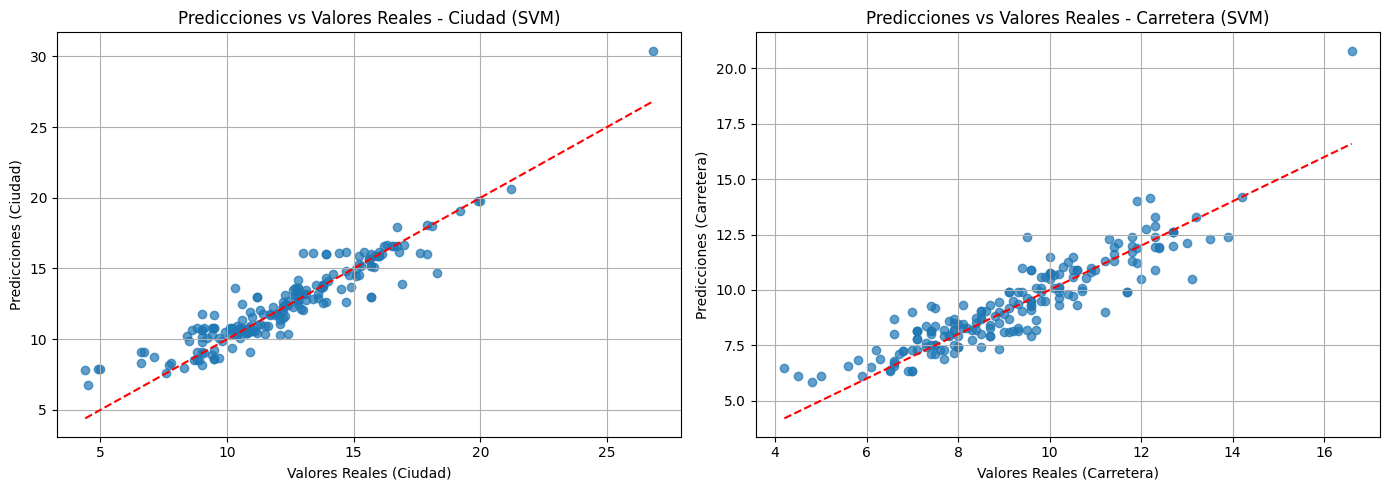

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_city, y_pred_city, alpha=0.7)
axes[0].plot([y_test_city.min(), y_test_city.max()],
             [y_test_city.min(), y_test_city.max()], 'r--')
axes[0].set_xlabel('Valores Reales (Ciudad)')
axes[0].set_ylabel('Predicciones (Ciudad)')
axes[0].set_title('Predicciones vs Valores Reales - Ciudad (SVM)')
axes[0].grid()

axes[1].scatter(y_test_hwy, y_pred_hwy, alpha=0.7)
axes[1].plot([y_test_hwy.min(), y_test_hwy.max()],
             [y_test_hwy.min(), y_test_hwy.max()], 'r--')
axes[1].set_xlabel('Valores Reales (Carretera)')
axes[1].set_ylabel('Predicciones (Carretera)')
axes[1].set_title('Predicciones vs Valores Reales - Carretera (SVM)')
axes[1].grid()

plt.tight_layout()
plt.show()

---

# Problema 9

Repita el problema 3 utilizando el modelo SVM de sklearn. Anote los hiperparámetros que elija y todas sus suposiciones.

### Librerías

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

### Carga de datos

In [48]:
# Generación de datos sintéticos
np.random.seed(14)
X = np.linspace(-np.pi, np.pi, 5000).reshape(-1, 1)
y = 1 - 2 ** (np.sin(-X.ravel() ** 2))

### Preprocesamiento de Datos

In [49]:
# Escalar y dividir
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=14)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 4000 muestras
Conjunto de prueba: 1000 muestras


### Entrenamiento

In [50]:
model = SVR(kernel='rbf', C=100, epsilon=0.01, gamma='scale')
model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [51]:
# Métricas
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print('-' * 60)
print(f"{'Modelo':<15} {'MSE':<15} {'RMSE':<15} {'R²':<15}")
print('-' * 60)
print(f"{'f(x)':<15} {mse:<15.4f} {rmse:<15.4f} {r2:<15.4f}")
print('-' * 60)

------------------------------------------------------------
Modelo          MSE             RMSE            R²             
------------------------------------------------------------
f(x)            0.0213          0.1460          0.8880         
------------------------------------------------------------


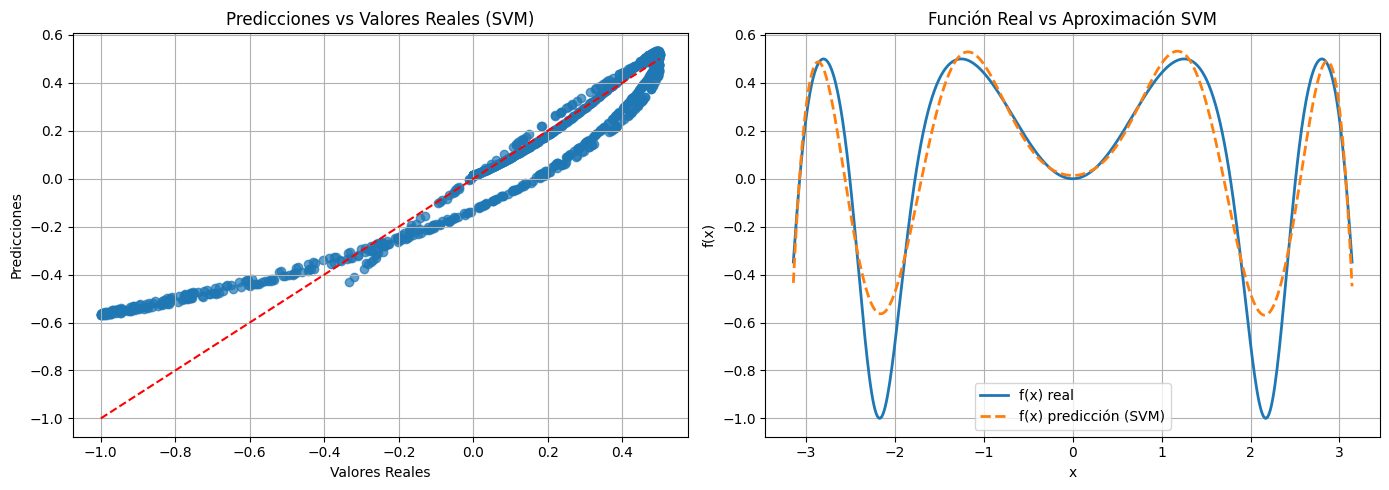

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicciones vs valores reales
axes[0].scatter(y_test, y_pred, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones')
axes[0].set_title('Predicciones vs Valores Reales (SVM)')
axes[0].grid()

# Curva ajustada vs función real
X_plot = np.linspace(-np.pi, np.pi, 500).reshape(-1, 1)
X_plot_scaled = scaler.transform(X_plot)
y_plot_real = 1 - 2 ** (np.sin(-X_plot.ravel() ** 2))
y_plot_pred = model.predict(X_plot_scaled)

axes[1].plot(X_plot, y_plot_real, label='f(x) real', linewidth=2)
axes[1].plot(X_plot, y_plot_pred, label='f(x) predicción (SVM)', linewidth=2, linestyle='--')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Función Real vs Aproximación SVM')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

---

# Problema 10

Repita el problema 4 utilizando el modelo SVM de sklearn. Anote los hiperparámetros que elija y todas sus suposiciones.

### Librerías

In [53]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from kagglehub import KaggleDatasetAdapter
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

### Carga de datos

In [54]:
file_path = "horse.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "yasserh/horsesurvivalprognostication",
    file_path
)

### Preprocesamiento de Datos

In [55]:
# Variable objetivo binaria
df['outcome_binary'] = (df['outcome'] == 'lived').astype(int)

# Eliminar columnas no relevantes
cols_to_drop = ['outcome', 'hospital_number', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data']
df = df.drop(columns=cols_to_drop)

# Separar features y target
X = df.drop('outcome_binary', axis=1)
y = df['outcome_binary']

# Imputar valores faltantes
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')
X[numeric_cols] = imputer_num.fit_transform(X[numeric_cols])
X[categorical_cols] = imputer_cat.fit_transform(X[categorical_cols])

# Codificación one-hot
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [56]:
# División y normalización
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=14, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 239 muestras
Conjunto de prueba: 60 muestras


### Entrenamiento

In [57]:
model = SVC(kernel='rbf', C=10, gamma='scale', random_state=14)
model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [58]:
# Métricas
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print('-' * 30)
print(f"{'Metrica':<20} {'Valor':<15}")
print('-' * 30)
print(f"{'Accuracy':<20} {acc:<15.4f}")
print(f"{'F1 (clase 1)':<20} {f1:<15.4f}")
print(f"{'F1 (macro)':<20} {f1_macro:<15.4f}")
print('-' * 30)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No sobrevivió', 'Sobrevivió']))

------------------------------
Metrica              Valor          
------------------------------
Accuracy             0.8167         
F1 (clase 1)         0.8533         
F1 (macro)           0.8044         
------------------------------

Reporte de clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.81      0.71      0.76        24
   Sobrevivió       0.82      0.89      0.85        36

     accuracy                           0.82        60
    macro avg       0.82      0.80      0.80        60
 weighted avg       0.82      0.82      0.81        60



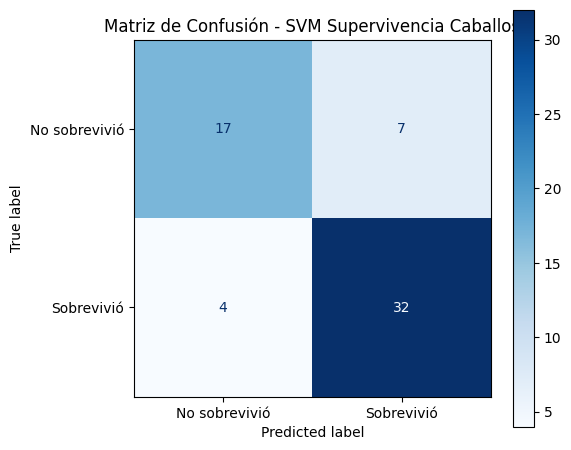

In [59]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No sobrevivió', 'Sobrevivió'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - SVM Supervivencia Caballos')
plt.tight_layout()
plt.savefig('images/p10_confusion_matrix.png', dpi=200)
plt.show()

---

# Problema 11

Repita el problema 5 utilizando el modelo SVM de sklearn. Anote los hiperparámetros que elija y todas sus suposiciones.

### Librerías

In [60]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler, LabelEncoder

### Carga de datos

In [61]:
file_path = "beer.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ankurnapa/ankurs-beer-data-set",
    file_path
)
df.head()

,Brew No.,OG,ABV,pH,IBU,style
0,1,11.5,4.2,4.20,14.0,Premium Lager
1,2,12.2,4.8,4.25,12.0,Premium Lager
2,3,13.0,5.0,3.80,13.0,Premium Lager
3,4,11.0,3.9,4.20,14.0,Premium Lager
4,5,12.0,4.2,3.90,12.0,Premium Lager


### Preprocesamiento de Datos

In [62]:
# Features y target
X = df[['OG', 'ABV', 'pH', 'IBU']]
y = df['style']

# Codificar target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.9, random_state=14, stratify=y_encoded)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 15 muestras
Conjunto de prueba: 135 muestras


### Entrenamiento

In [63]:
# Modelo SVM
model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=14
)
model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [64]:
# Métricas
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print('-' * 30)
print(f"{'Metrica':<20} {'Valor':<15}")
print('-' * 30)
print(f"{'Accuracy':<20} {acc:<15.4f}")
print(f"{'F1 (macro)':<20} {f1_macro:<15.4f}")
print(f"{'F1 (weighted)':<20} {f1_weighted:<15.4f}")
print('-' * 30)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=class_names))

------------------------------
Metrica              Valor          
------------------------------
Accuracy             0.9926         
F1 (macro)           0.9926         
F1 (weighted)        0.9926         
------------------------------

Reporte de clasificación:
               precision    recall  f1-score   support

          IPA       1.00      1.00      1.00        45
  Light Lager       0.98      1.00      0.99        45
Premium Lager       1.00      0.98      0.99        45

     accuracy                           0.99       135
    macro avg       0.99      0.99      0.99       135
 weighted avg       0.99      0.99      0.99       135



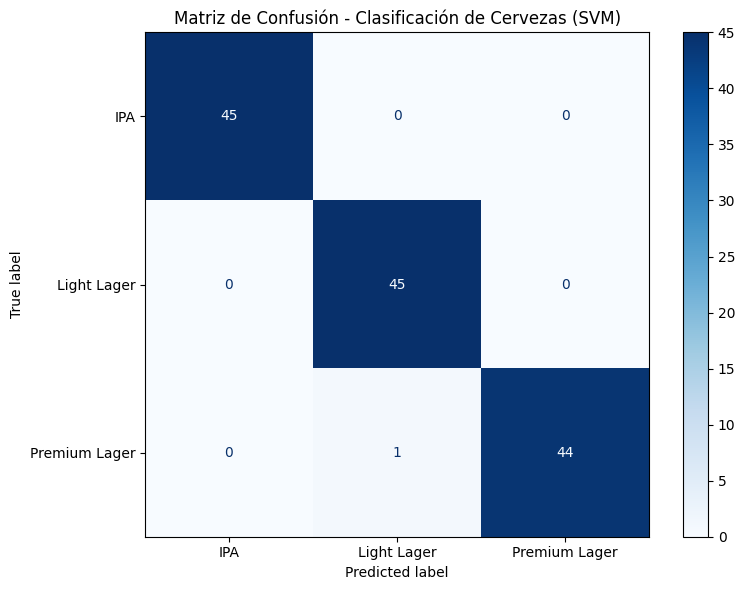

In [65]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - Clasificación de Cervezas (SVM)')
plt.tight_layout()
plt.savefig('images/p11.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Problema 12

Repita el problema 6 utilizando el modelo SVM de sklearn. Anote los hiperparámetros que elija y todas sus suposiciones.

### Librerías

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

### Carga de datos

In [67]:
np.random.seed(14)

def generate_quadratic_data(n_samples=3000):
    data = []
    samples_per_class = n_samples // 3

    # Clase 2: Raíces reales distintas (Δ > 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        max_c = (b**2) / (4 * abs(a)) - 0.1
        c = np.random.uniform(-10, min(10, max_c))
        discriminant = b**2 - 4*a*c
        if discriminant > 0:
            data.append([a, b, c, 2])
            count += 1

    # Clase 1: Raíz real doble (Δ ≈ 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        c = (b**2) / (4 * a) + np.random.uniform(-0.05, 0.05)
        data.append([a, b, c, 1])
        count += 1

    # Clase 0: Raíces complejas (Δ < 0)
    count = 0
    while count < samples_per_class:
        a = np.random.uniform(-10, 10)
        while abs(a) < 0.1:
            a = np.random.uniform(-10, 10)
        b = np.random.uniform(-10, 10)
        min_c = (b**2) / (4 * abs(a)) + 0.1
        c = np.random.uniform(min(min_c, 10), 10)
        discriminant = b**2 - 4*a*c
        if discriminant < 0:
            data.append([a, b, c, 0])
            count += 1

    df = pd.DataFrame(data, columns=['a', 'b', 'c', 'root_type'])
    return df

# Generar dataset
df = generate_quadratic_data(n_samples=3000)

print(f"Dataset generado: {df.shape[0]} ecuaciones cuadráticas")
print(f"Distribución por clase:")
print(df['root_type'].value_counts().sort_index())

Dataset generado: 3000 ecuaciones cuadráticas
Distribución por clase:
root_type
0    1000
1    1000
2    1000
Name: count, dtype: int64


### Preprocesamiento de Datos

In [68]:
# Separar features y target
X = df[['a', 'b', 'c']]
y = df['root_type']

# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14, stratify=y
)

# Normalización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Conjunto de entrenamiento: {X_train_scaled.shape}")
print(f"Conjunto de prueba: {X_test_scaled.shape}")

Conjunto de entrenamiento: (2400, 3)
Conjunto de prueba: (600, 3)


### Entrenamiento

In [69]:
# Modelo SVM
model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=14
)
model.fit(X_train_scaled, y_train)
print("Modelo entrenado.")

Modelo entrenado.


### Evaluación

In [70]:
# Métricas
y_pred = model.predict(X_test_scaled)
class_names = ['Complejas\n(Δ<0)', 'Doble\n(Δ≈0)', 'Reales\n(Δ>0)']

train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
train_f1 = f1_score(y_train, model.predict(X_train_scaled), average='weighted')
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')

print("-" * 42)
print("Resultados del Modelo SVM")
print("-" * 42)
print(f"Train Accuracy: {train_acc:.4f}, Train F1: {train_f1:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}, Test F1:  {test_f1:.4f}")
print("-" * 42)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred,
                            target_names=['Complejas', 'Doble', 'Reales distintas']))

------------------------------------------
Resultados del Modelo SVM
------------------------------------------
Train Accuracy: 0.9383, Train F1: 0.9392
Test Accuracy:  0.9417, Test F1:  0.9423
------------------------------------------

Reporte de clasificación:
                  precision    recall  f1-score   support

       Complejas       0.96      0.94      0.95       200
           Doble       0.87      0.97      0.92       200
Reales distintas       1.00      0.92      0.96       200

        accuracy                           0.94       600
       macro avg       0.95      0.94      0.94       600
    weighted avg       0.95      0.94      0.94       600



<Figure size 800x600 with 0 Axes>

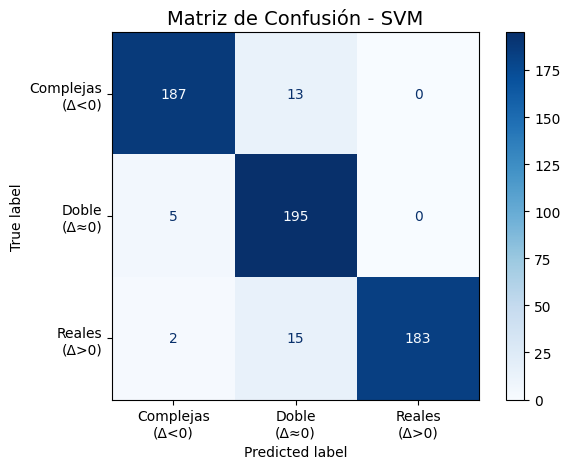

In [71]:
# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - SVM', fontsize=14)
plt.tight_layout()
plt.savefig('images/p12.png', dpi=150, bbox_inches='tight')
plt.show()